En este segundo experimento se busca observar qué ocurre cuando esas mismas condiciones se utilizan para producir diferentes recorridos.

La pregunta es:

**¿Cómo pueden pequeñas diferencias en las condiciones de un recorrido producir formas diferentes?**

En esta etapa se mantienen:

- **Contención**
- **Ruido**
- **Acumulación**
- **Torsión**

y se explora cómo sus variaciones modifican la forma de las trenzas.

### ¿Qué hace `np.random.seed(42)`?

El experimento utiliza ruido aleatorio para producir pequeñas variaciones.

`np.random.seed(42)` hace que ese azar sea **repetible**: cada vez que se ejecuta el código se obtiene la misma secuencia de valores aleatorios.

Esto permite comparar los resultados cuando cambiamos otros parámetros del experimento.

El número `42` es simplemente una semilla elegida para fijar esa secuencia.

```text
SIN seed
   ↓
azar diferente cada vez
   ↓
resultado diferente

CON seed = 42
   ↓
mismo azar
   ↓
resultado comparable

In [2]:
# ----------------------------------------------------------
# EXPERIMENTO 02 — TRAMAS / TRENZAS
# ----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

Aquí todavía no se ha generado la trenza. Solo dse definen las condiciones que controlarán el recorrido.

la línea se va construyendo paso a paso, avanzando desde una posición inicial hacia una nueva posición.

No es movimiento físico de un objeto; es un recorrido matemático:

posición inicial
      ↓
   pequeño paso
      ↓
 nueva posición
      ↓
   pequeño paso
      ↓
 nueva posición
      ↓
      ...
      ↓
 trayectoria

 x = np.linspace(0, longitud * paso, longitud)

define hacia dónde avanza el recorrido.

Y:

y[i] = y[i-1] + ruido + memoria

define cómo se desvía la trayectoria mientras avanza.

Por eso es mejor hablar de recorrido o trayectoria que de "movimiento": el código está construyendo una línea que avanza y se transforma a lo largo de su recorrido.

In [4]:
# ----------------------------------------------------------
# CELDA 2 — PARÁMETROS
# ----------------------------------------------------------

longitud = 1000

# Tamaño de cada paso
paso = 0.01

# Intensidad del ruido
ruido = 0.08

# Acumulación de las desviaciones
entropia = 0.015

# Límite de contención
limite = 1.5

# Separación entre las hebras
separacion = 0.18

In [5]:
# ----------------------------------------------------------
# CELDA 3 — CREAR EL RECORRIDO
# ----------------------------------------------------------

x = np.linspace(0, longitud * paso, longitud)

# Posición inicial del recorrido
y = np.zeros(longitud)

# Memoria de las desviaciones anteriores
memoria = 0

for i in range(1, longitud):

    # Nueva desviación aleatoria
    r = np.random.normal(0, ruido)

    # Se acumula una pequeña parte de la desviación
    memoria += r * entropia

    # Nueva posición:
    # posición anterior + ruido + memoria
    y[i] = y[i-1] + r + memoria

X → hacia dónde avanza el recorrido

Y → cómo se desvía

ruido → nueva desviación

memoria → parte de lo ocurrido anteriormente

Aquí aun no se aplica la contención ni se hacen las tres hebras. Primero ver cómo se comporta este recorrido por sí solo.

In [6]:
# ----------------------------------------------------------
# CELDA 4 — CONTENCIÓN DEL RECORRIDO
# ----------------------------------------------------------

for i in range(1, longitud):

    if y[i] > limite:
        y[i] = limite
        memoria *= -0.5

    if y[i] < -limite:
        y[i] = -limite
        memoria *= -0.5

La idea es :

recorrido
    ↓
desviación
    ↓
¿llegó al límite?
   ↙       ↘
 sí        no
 ↓          ↓
contener    continuar

Contención = define y guía el espacio en el que puede desarrollarse el recorrido.

Celda 5 — Visualizar el recorrido

Ahora se puede ver qué produjo el código antes de convertirlo en tres hebras.

Aquí se ve una sola trayectoria irregular.

recorrido
    ↓
ruido + acumulación
    ↓
contención
    ↓
trayectoria

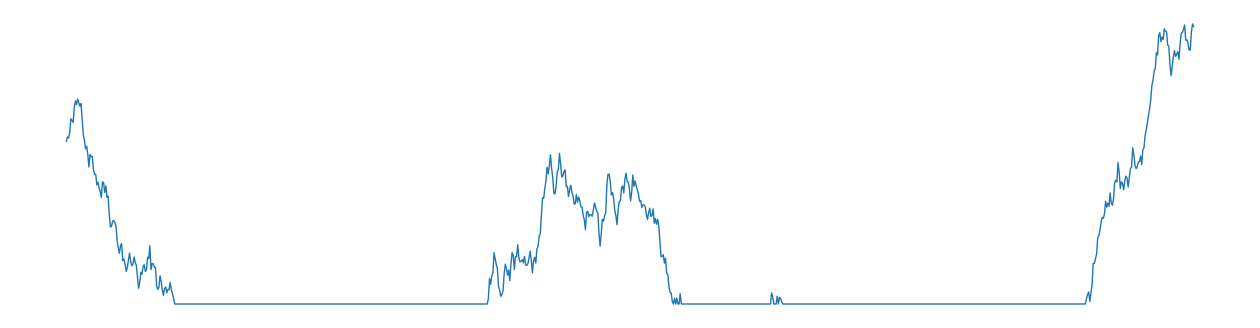

In [7]:
# ----------------------------------------------------------
# CELDA 5 — VISUALIZAR EL RECORRIDO
# ----------------------------------------------------------

plt.figure(figsize=(16, 4))

plt.plot(x, y, linewidth=1)

plt.axis("off")
plt.show()

Celda 6 — Crear las tres hebras

Ahora se usa el recorrido y como base para crear tres hebras.

In [8]:
# ----------------------------------------------------------
# CELDA 6 — TRES HEBRAS
# ----------------------------------------------------------

separacion = 0.18

hebra_1 = y + separacion
hebra_2 = y
hebra_3 = y - separacion

Todavía no están entrelazadas.

En la siguiente celda se podrá introducir la torsión, que hará que las tres hebras se muevan alrededor del eje y aparezca realmente la estructura de trenza.

Y se hace que las tres hebras se separen y se alternen alrededor de un eje. Así se deja de tener tres líneas paralelas y comienza a construir el entrelazamiento.

In [9]:
# ----------------------------------------------------------
# CELDA 7 — TORSIÓN
# ----------------------------------------------------------

radio = 0.22

# Cantidad de giro a lo largo del recorrido
angulo = np.linspace(0, 18 * np.pi, longitud)

# Tres posiciones separadas 120°
hebra_1 = y + radio * np.sin(angulo)
hebra_2 = y + radio * np.sin(angulo + 2 * np.pi / 3)
hebra_3 = y + radio * np.sin(angulo + 4 * np.pi / 3)

La idea es:

             eje
              ↓
            radio
              ↓
           torsión
              ↓
       3 posiciones
          120° / 120° / 120°
              ↓
       tres hebras
              ↓
           trenza

Aquí la trayectoria y sigue siendo la base. La torsión se agrega alrededor de ella, a trayectoria es el camino central y la torsión hace que las tres hebras giren alrededor de ese camino.


Celda 8 — Visualizar la trenza

Ahora dibujamos las tres hebras para comprobar qué produjo la torsión:

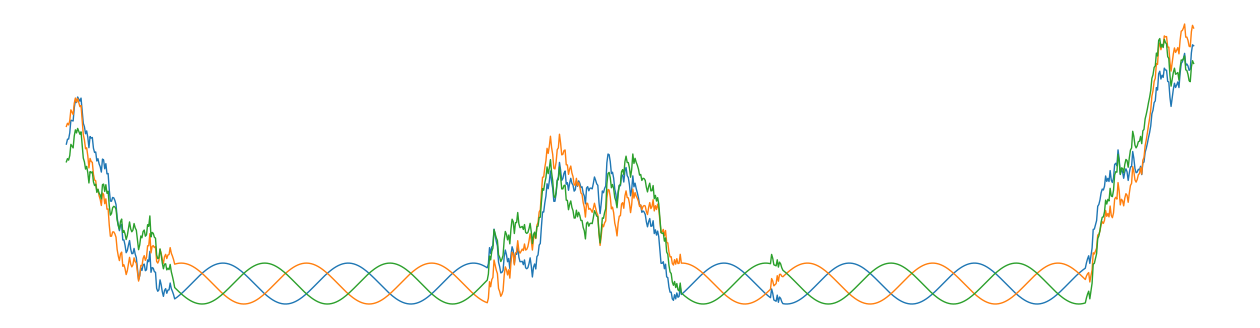

In [10]:
# ----------------------------------------------------------
# CELDA 8 — VISUALIZAR LA TRENZA
# ----------------------------------------------------------

plt.figure(figsize=(16, 4))

plt.plot(x, hebra_1, linewidth=1)
plt.plot(x, hebra_2, linewidth=1)
plt.plot(x, hebra_3, linewidth=1)

plt.axis("off")
plt.show()

TRAYECTORIA
    ↓
TORSIÓN
    ↓
3 HEBRAS QUE CAMBIAN DE POSICIÓN
    ↓
ENTRELAZAMIENTO

Esta es la primera prueba visual de la trenza como recorrido.

Celda 9 — Generar una trenza

Ahora reunimos lo anterior en una función.

La función generar_trenza() recibe los parámetros de una trenza y construye:

ruido
  ↓
acumulación
  ↓
contención
  ↓
torsión
  ↓
3 hebras
  ↓
trenza

Así se poueden cambiar los parámetros y generar diferentes trenzas sin escribir nuevamente todo el código.

Diferentes formas → cambian según sus parámetros: ruido, entropía, contención, torsión y radio.

Diferentes colores → cada trenza recibe una tríada de la paleta de 8 colores.

Entonces la idea de la celda 9 podría quedar:

parámetros
   ↓
generar_trenza()
   ↓
forma diferente
   +
tríada de colores diferente
   ↓
trenza

Así, cada una de las 24 trenzas puede tener un comportamiento y una combinación de colores propios, aunque todas siguen las mismas reglas.

In [11]:
# ----------------------------------------------------------
# 24 TRENZAS — PARÁMETROS
# ----------------------------------------------------------

np.random.seed(42)

n_trenzas = 24

parametros = []

for i in range(n_trenzas):

    parametros.append({
        "id": i + 1,
        "limite": np.random.uniform(0.7, 1.5),
        "ruido": np.random.uniform(0.015, 0.08),
        "entropia": np.random.uniform(0.003, 0.04),
        "torsion": np.random.uniform(12, 25),
        "radio": np.random.uniform(0.12, 0.30)
    })

parametros[:3]

[{'id': 1,
  'limite': 0.99963209507789,
  'ruido': 0.07679642991664455,
  'entropia': 0.030083775847021987,
  'torsion': 19.782560294561478,
  'radio': 0.14808335527963856},
 {'id': 2,
  'limite': 0.824795616268962,
  'ruido': 0.018775434790932966,
  'entropia': 0.0350485173936726,
  'torsion': 19.814495152661713,
  'radio': 0.24745306400328818},
 {'id': 3,
  'limite': 0.716467595436642,
  'ruido': 0.07804414039052963,
  'entropia': 0.0338003777096156,
  'torsion': 14.76040843881759,
  'radio': 0.15272849409727812}]

Por ejemplo, la Trenza 1 tiene:

contención  → 0.9996
ruido       → 0.0768
entropía    → 0.0301
torsión     → 19.78
radio       → 0.1481

Y la Trenza 2 recibe otros valores.....
Lo importante conceptualmente es:

MISMAS REGLAS
      ↓
DISTINTOS PARÁMETROS
      ↓
DISTINTAS FORMAS

Celda 11 — Generar una trenza con sus parámetros

Ahora hacer que una función reciba los parámetros de cada trenza y construya su recorrido.

In [13]:
# ----------------------------------------------------------
# TRENZA — 3 HEBRAS CON VARIACIÓN PROPIA
# ----------------------------------------------------------

def generar_trenza(param, N=1200):

    x = np.linspace(0, 12, N)

    # ------------------------------------------------------
    # 1. EJE PRINCIPAL
    # ------------------------------------------------------

    eje = np.zeros(N)
    memoria = 0

    for i in range(1, N):

        ruido_actual = np.random.normal(
            0,
            param["ruido"]
        )

        memoria = (
            memoria * 0.985
            + ruido_actual * param["entropia"]
        )

        eje[i] = (
            eje[i-1]
            + ruido_actual
            - memoria
        )

    # ------------------------------------------------------
    # 2. CONTENCIÓN
    # ------------------------------------------------------

    limite = param["limite"]

    eje = np.tanh(eje / limite) * limite

    # ------------------------------------------------------
    # 3. TORSIÓN
    # ------------------------------------------------------

    angulo = np.linspace(
        0,
        param["torsion"] * np.pi,
        N
    )

    radio = param["radio"]

    # ------------------------------------------------------
    # 4. TRES HEBRAS
    # ------------------------------------------------------

    h1 = eje + radio * np.sin(angulo)

    h2 = eje + radio * np.sin(
        angulo + 2*np.pi/3
    )

    h3 = eje + radio * np.sin(
        angulo + 4*np.pi/3
    )

    # ------------------------------------------------------
    # 5. MICRO-DESVIACIONES
    # ------------------------------------------------------

    h1 += np.random.normal(
        0,
        param["ruido"] * 0.25,
        N
    )

    h2 += np.random.normal(
        0,
        param["ruido"] * 0.35,
        N
    )

    h3 += np.random.normal(
        0,
        param["ruido"] * 0.45,
        N
    )

    return x, h1, h2, h3

    # esta función toma los parámetros de una trenza y los convierte
    # en una forma de tres hebras, con sus propias pequeñas variaciones.

Celda 12 — Crear la paleta de colores

Ahora definimos los 8 colores base que utilizaremos para las 24 trenzas.

In [14]:
# ----------------------------------------------------------
# PALETA BASE
# ----------------------------------------------------------

colores_base = [
    "#E63946",
    "#F4A261",
    "#E9C46A",
    "#2A9D8F",
    "#264653",
    "#457B9D",
    "#A8DADC",
    "#6D597A"
]

# La idea es tener una misma paleta para todo el conjunto. Luego estos 8 colores se combinarán en grupos de 3 para asignarlos a las 24 trenzas.

# 8 colores

# combinaciones de 3

# 24 trenzas

Celda 13 — Crear las 24 combinaciones de color

Ahora definimos qué tres colores tendrá cada una de las 24 trenzas.

In [15]:
# ----------------------------------------------------------
# 24 TRÍADAS DE COLOR
# ----------------------------------------------------------

combinaciones = [
    (0, 1, 2),
    (0, 2, 3),
    (1, 3, 2),
    (3, 4, 5),
    (3, 5, 6),
    (4, 6, 5),
    (6, 7, 0),
    (6, 0, 1),
    (7, 1, 0),
    (1, 2, 4),
    (1, 4, 5),
    (2, 5, 4),
    (2, 3, 6),
    (2, 6, 7),
    (3, 7, 6),
    (0, 4, 6),
    (0, 6, 7),
    (4, 7, 6),
    (1, 5, 7),
    (1, 7, 3),
    (5, 3, 7),
    (0, 2, 5),
    (2, 4, 7),
    (0, 5, 3)
]

Los números son índices que apuntan a los 8 colores de la celda anterior.

Por ejemplo:

(0, 1, 2)
   ↓
color 0 + color 1 + color 2
   ↓
Trenza 01



-----

Celda 14 — Convertir los índices en colores

Ahora convertimos los números de la celda anterior en los colores reales.

In [16]:
# ----------------------------------------------------------
# CONVERTIR ÍNDICES EN COLORES
# ----------------------------------------------------------

paletas = []

for combinacion in combinaciones:

    paleta = [
        colores_base[i]
        for i in combinacion
    ]

    paletas.append(paleta)

print("Número de trenzas:", len(paletas))

for i, paleta in enumerate(paletas):
    print(f"Trenza {i+1:02d}:", paleta)

Número de trenzas: 24
Trenza 01: ['#E63946', '#F4A261', '#E9C46A']
Trenza 02: ['#E63946', '#E9C46A', '#2A9D8F']
Trenza 03: ['#F4A261', '#2A9D8F', '#E9C46A']
Trenza 04: ['#2A9D8F', '#264653', '#457B9D']
Trenza 05: ['#2A9D8F', '#457B9D', '#A8DADC']
Trenza 06: ['#264653', '#A8DADC', '#457B9D']
Trenza 07: ['#A8DADC', '#6D597A', '#E63946']
Trenza 08: ['#A8DADC', '#E63946', '#F4A261']
Trenza 09: ['#6D597A', '#F4A261', '#E63946']
Trenza 10: ['#F4A261', '#E9C46A', '#264653']
Trenza 11: ['#F4A261', '#264653', '#457B9D']
Trenza 12: ['#E9C46A', '#457B9D', '#264653']
Trenza 13: ['#E9C46A', '#2A9D8F', '#A8DADC']
Trenza 14: ['#E9C46A', '#A8DADC', '#6D597A']
Trenza 15: ['#2A9D8F', '#6D597A', '#A8DADC']
Trenza 16: ['#E63946', '#264653', '#A8DADC']
Trenza 17: ['#E63946', '#A8DADC', '#6D597A']
Trenza 18: ['#264653', '#6D597A', '#A8DADC']
Trenza 19: ['#F4A261', '#457B9D', '#6D597A']
Trenza 20: ['#F4A261', '#6D597A', '#2A9D8F']
Trenza 21: ['#457B9D', '#2A9D8F', '#6D597A']
Trenza 22: ['#E63946', '#E9C46A',

Ahora cada trenza tiene su propia combinación de tres colores.

---------

Celda 15 — Dibujar las 24 trenzas

Ahora juntamos todo: los parámetros + la función + los colores y dibujamos las 24 trenzas.

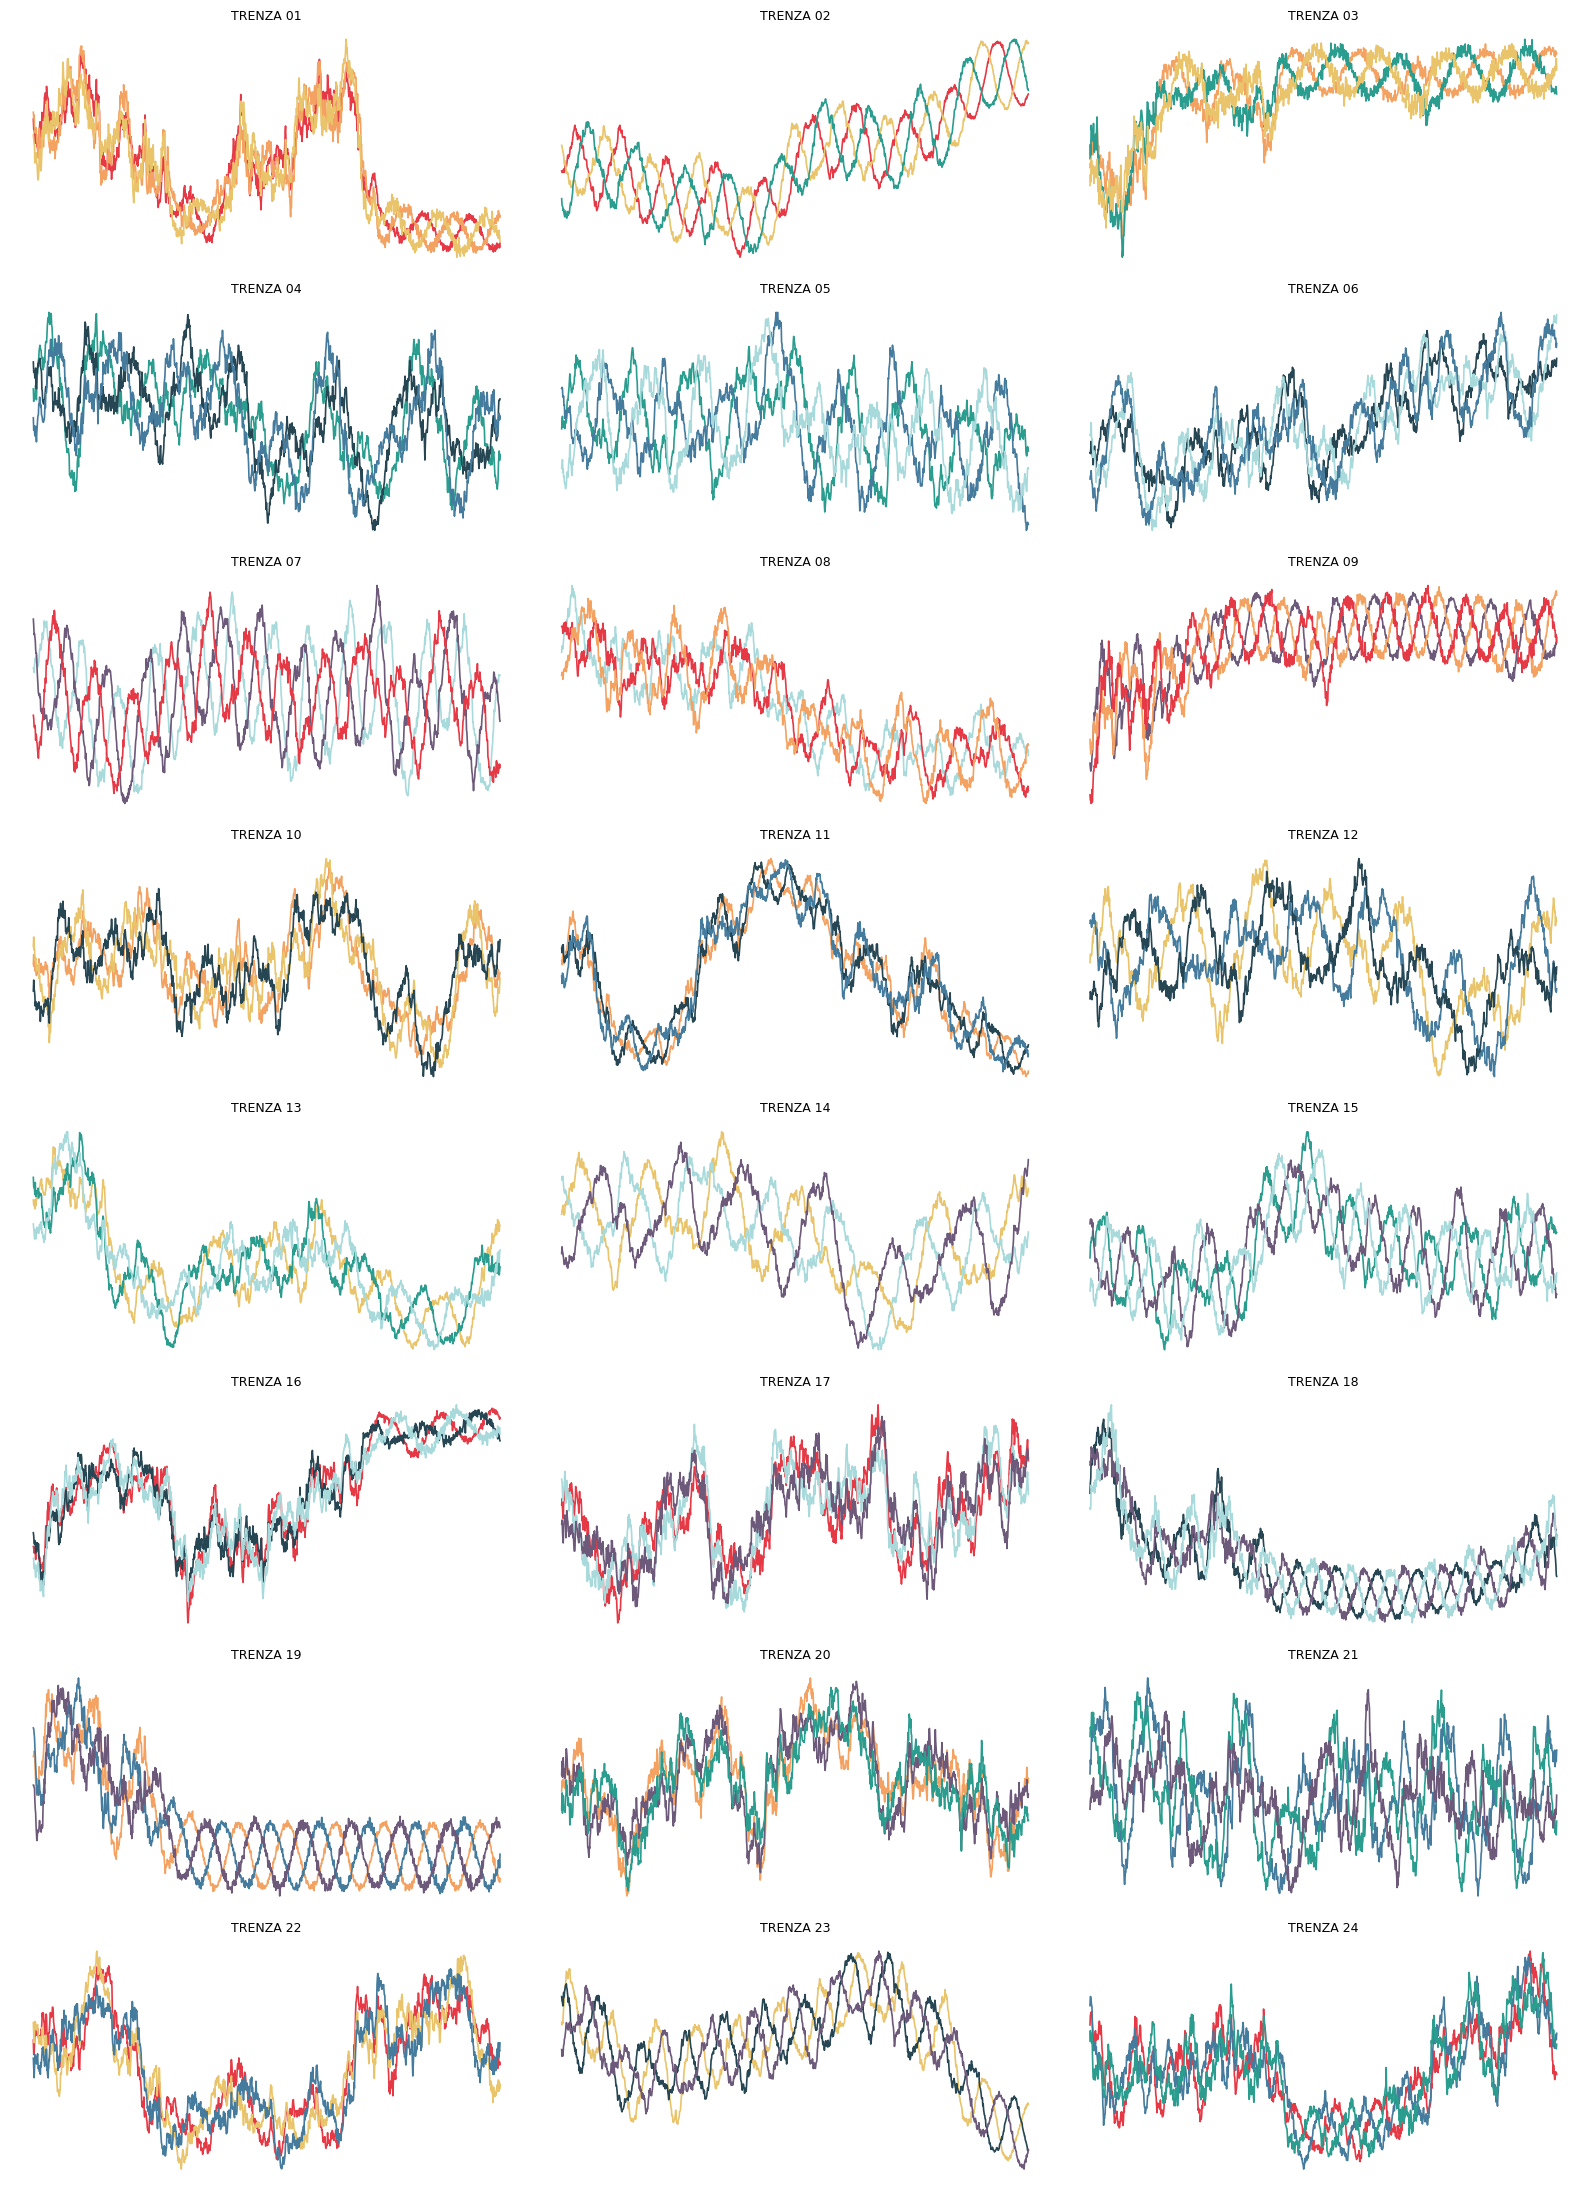

In [17]:
# ----------------------------------------------------------
# CELDA 15 — DIBUJAR LAS 24 TRENZAS
# ----------------------------------------------------------

fig, axes = plt.subplots(
    8,
    3,
    figsize=(16, 22)
)

for i, param in enumerate(parametros):

    # Generar la forma
    x, h1, h2, h3 = generar_trenza(param)

    # Obtener los tres colores
    colores = paletas[i]

    # Seleccionar el espacio de dibujo
    ax = axes.flat[i]

    # Dibujar las tres hebras
    ax.plot(x, h1, color=colores[0], linewidth=1.2)
    ax.plot(x, h2, color=colores[1], linewidth=1.2)
    ax.plot(x, h3, color=colores[2], linewidth=1.2)

    ax.set_title(
        f"TRENZA {i+1:02d}",
        fontsize=9
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

Aquí finalmente ocurre:

24 parámetros
      ↓
generar_trenza()
      ↓
24 formas
      +
24 tríadas de color
      ↓
24 TRENZAS

Esta es la primera versión completa del experimento: las 24 trenzas comparten las mismas reglas, pero cada una tiene sus propios parámetros y colores.